In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import emcee, corner
from sbi import utils as sbi_utils
from sbi.inference import NPE, simulate_for_sbi
from sbi.neural_nets import posterior_nn
from matplotlib.patches import Patch

In [17]:
"""
Wave Parameter Recovery with SBI — Class Implementation
===================================================================

Unified interface for recovering wave parameters using SBI/NPE.

NOISE MODEL: Sine wave with noise on datapoints:
  wave_obs = A * sin(ω * x) + ε,  ε ~ N(0, σ²)

Usage:
    study = WaveSBI(
        n_points=50,
        n_simulations=10000,
        noise_std=0.8
    )
    study.run_all()
"""

class LinearMLPEmbedding(nn.Module):
    """Embedding network for wave parameter recovery. The output of this summary extractor 
    made of a linear layer + MLP will be used as input to the SBI density estimator.
    """

    def __init__(self, n_points: int, ncomponents: int, hidden_dims: list = [64, 64], mlp_out_dim: int = 16):
        super().__init__()
        # Classifier head
        self.linear = nn.Linear(n_points, ncomponents)  

        # MLP on top of the compressed representation
        layers = []
        in_dim = ncomponents
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        layers.append(nn.Linear(in_dim, mlp_out_dim))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.linear(x))
        x = self.mlp(x)
        return x


class WaveSBI:
    """
    Unified interface for comparing MCMC and SBI/NPE on wave parameter recovery.
    
    Noise Model: wave_obs = A * sin(ω * x) + ε  (wave noise, constant measurement error)
    
    Attributes:
        n_points : int
            Number of measurement positions
        n_simulations : int
            Number of simulations for SBI training
        noise_std : float
            Standard deviation of wave measurement noise
        true_A : float
            True amplitude (units)
        true_omega : float
            True angular frequency (rad/s)
    """
    
    def __init__(self, n_points=50, n_simulations=10000, noise_std=0.8,
                 true_A=1.0, true_omega=2.0, seed=42, n_posterior=10000, ncomponents=10, hidden_dims=[64, 64], mlp_out_dim=16):
        """
        Initialize the Wave Parameter Recovery study.
        
        Parameters:
        -----------
        n_points : int, default=50
            Number of measurement points (spatial positions)
        n_simulations : int, default=10000
            Number of simulations to generate for SBI training
        noise_std : float, default=0.8
            Standard deviation of wave measurement noise
        true_A : float, default=1.0
            True amplitude (units)
        true_omega : float, default=2.0
            True angular frequency (rad/s)
        seed : int, default=42
            Random seed for reproducibility
        n_posterior : int, default=5000
            Number of posterior samples to draw from SBI
        ncomponents : int, default=10
            Number of output components in the linear layer
        hidden_dims : list, default=[64, 64]
            List of hidden layer dimensions for the MLP
        mlp_out_dim : int, default=16
            Output dimension of the MLP
        """
        # Store parameters
        self.n_points = n_points
        self.n_simulations = n_simulations
        self.noise_std = noise_std
        self.true_A = true_A
        self.true_omega = true_omega
        self.seed = seed
        self.n_posterior = n_posterior
        self.ncomponents = ncomponents
        self.hidden_dims = hidden_dims
        self.mlp_out_dim = mlp_out_dim
    
        # Initialize random seeds
        self.rng = np.random.default_rng(seed)
        torch.manual_seed(seed)
        
        # Create measurement positions and observed data
        self.x_positions = np.linspace(-2.0, 2.0, n_points)
        self.wave_observed = self._generate_observed_data()
  
        # Add linear layer+mulitlayer perceptron as "binning"
        # Summary network: linear compression + MLP
        # Input dim  = n_points  (one simulation's data vector)
        # Output dim = mlp_out_dim  (fed into NPE's density estimator)
        self.embedding_net = LinearMLPEmbedding(
            n_points    = n_points,
            ncomponents = ncomponents,
            hidden_dims = hidden_dims,
            mlp_out_dim = mlp_out_dim,
        )

        # Results storage
        self.sbi_samples_np = None
        self.A_sbi = None
        self.omega_sbi = None
        self.posterior = None
        
    def _generate_observed_data(self):
        """Synthetic noisy wave: wave_obs = A*sin(ω*x) + ε,  ε~N(0,σ²)"""
        wave_clean = self.true_A * np.sin(self.true_omega * self.x_positions)
        self.wave_noise = self.rng.normal(0, self.noise_std, self.n_points)
        return wave_clean + self.wave_noise

    
    # SBI / NPE

    def run_sbi(self, verbose=True):
        """
        Run SBI/NPE training with the LinearMLP embedding network.

        The simulator returns raw wave data (n_points per simulation).
        The embedding_net compresses each vector to mlp_out_dim features
        before the NPE density estimator sees it.
        """
        if verbose:
            print("=" * 60)
            print("SBI — Neural Posterior Estimation (NPE)")
            print(f"  Summary net: Linear({self.n_points}→{self.ncomponents})"
                  f" + ReLU + MLP{self.hidden_dims}→{self.mlp_out_dim}")
            print("=" * 60)

        # Step 1: prior
        prior = sbi_utils.BoxUniform(
            low  = torch.tensor([0.0,  0.0]),
            high = torch.tensor([5.0, 20.0])
        )

        # Step 2: simulator — returns raw wave_obs, shape (batch, n_points)
        x_torch = torch.tensor(self.x_positions, dtype=torch.float32)

        def wave_simulator(theta):
            """
            Simulator for wave measurements.
            Input  theta : (batch, 2)  [A, omega]
            Output       : (batch, n_points)  raw noisy wave
            """
            if theta.dim() == 1:
                theta = theta.unsqueeze(0)

            A     = theta[:, 0]  # (batch,)
            omega = theta[:, 1]  # (batch,)

            # wave_clean : (batch, n_points)
            wave_clean = (A.unsqueeze(1)
                          * torch.sin(omega.unsqueeze(1) * x_torch.unsqueeze(0)))
            noise      = self.noise_std * torch.randn_like(wave_clean)
            return wave_clean + noise   # (batch, n_points) — raw, no binning

        # Step 3: generate simulations
        if verbose:
            print(f"\nGenerating {self.n_simulations} simulations …")

        theta_sim, x_sim = simulate_for_sbi(
            simulator      = wave_simulator,
            proposal       = prior,
            num_simulations = self.n_simulations,
        )

        if verbose:
            print(f"  theta_sim : {theta_sim.shape}")
            print(f"  x_sim     : {x_sim.shape}")

        # debug to check if the weights are chaninging
        before = self.embedding_net.linear.weight.detach().clone()
        print("Linear layer+MLP summary extractor weights before training:")
        print(before)

        # Step 4: train NPE with the embedding net
        if verbose:
            print("\nTraining NPE …")

        neural_posterior = posterior_nn(model="nsf",  
        embedding_net=self.embedding_net,)

        #inference = NPE(prior=prior, embedding_net=self.embedding_net)
        inference = NPE(prior=prior, density_estimator=neural_posterior)
        density_estimator = (inference.append_simulations(theta_sim, x_sim).train(show_train_summary=verbose))

        # debug to check if the weights are chaninging
        print("Linear layer+MLP summary extractor weights after training:")
        after = self.embedding_net.linear.weight.detach().clone()
        print(after)      
        print("Difference between before and after training:")  
        print(torch.norm(after - before))
        
        # Step 5: build posterior and sample
        self.posterior = inference.build_posterior(density_estimator)

        # Observation tensor: raw wave, shape (n_points,)
        x_obs_torch = torch.tensor(self.wave_observed, dtype=torch.float32)

        sbi_samples = self.posterior.sample(
            (self.n_posterior,),
            x = x_obs_torch,
        )
        self.sbi_samples_np = sbi_samples.numpy()
        self.A_sbi     = np.median(self.sbi_samples_np[:, 0])
        self.omega_sbi = np.median(self.sbi_samples_np[:, 1])

        if verbose:
            print(f"\nSBI/NPE: A = {self.A_sbi:.3f},  omega = {self.omega_sbi:.3f}")
            print(f"         (true: {self.true_A}, {self.true_omega})\n")
    
# ---- Plotting -----------------------------------------------

    def plot_comparison(self, figsize=(15, 4)):
        print("\nPlotting …")
        x_line = np.linspace(self.x_positions.min(), self.x_positions.max(), 200)

        # ── 3-panel figure: predictive | P(A|data) | P(ω|data) ──────────────
        fig, axes = plt.subplots(1, 3, figsize=figsize)   # 1 row, not 2
        fig.suptitle("SBI (NPE) — Wave Parameter Recovery", fontsize=14)

        # (a) Posterior predictive
        ax = axes[0]
        pp_idx = self.rng.integers(self.n_posterior, size=200)
        for s in self.sbi_samples_np[pp_idx]:
            ax.plot(x_line, s[0] * np.sin(s[1] * x_line),   # FIX 1: np.sin, use both params
                    color="darkblue", alpha=0.05, lw=1)
        ax.errorbar(self.x_positions, self.wave_observed, yerr=np.abs(self.wave_noise), fmt = 'o', 
                color="tomato", zorder=5, markersize=2,linestyle = 'none', label="Data")
        ax.plot(x_line, self.true_A * np.sin(self.true_omega * x_line),   # FIX 2: np.sin
                "k--", lw=2, label=f"True A={self.true_A}, ω={self.true_omega}")
        ax.plot(x_line, self.A_sbi * np.sin(self.omega_sbi * x_line),
                "darkorange", lw=2, label=f"SBI  A={self.A_sbi:.2f}, ω={self.omega_sbi:.2f}")
        ax.set(xlabel="Position (m)", ylabel="Amplitude", title="Posterior predictive")
        ax.legend(fontsize=8)

        # (b) Marginal posterior for A
        ax = axes[1]
        ax.hist(self.sbi_samples_np[:, 0], bins=40, density=True,
                color="darkorange", alpha=0.7)
        ax.axvline(self.true_A, color="black", lw=2, ls="--", label=f"True A={self.true_A}")
        ax.axvline(self.A_sbi,  color="tomato", lw=2,          label=f"Median={self.A_sbi:.2f}")
        lo, hi = np.percentile(self.sbi_samples_np[:, 0], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="A", ylabel="Density", title="P(A | data)")
        ax.legend(fontsize=8)

        # (c) Marginal posterior for ω
        ax = axes[2]
        ax.hist(self.sbi_samples_np[:, 1], bins=40, density=True,
                color="darkorange", alpha=0.7)
        ax.axvline(self.true_omega, color="black", lw=2, ls="--", label=f"True ω={self.true_omega}")
        ax.axvline(self.omega_sbi,  color="tomato", lw=2,          label=f"Median={self.omega_sbi:.2f}")
        lo, hi = np.percentile(self.sbi_samples_np[:, 1], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="ω (rad/s)", ylabel="Density", title="P(ω | data)")
        ax.legend(fontsize=8)

        plt.tight_layout()
        #plt.savefig("sbi_wave_results.png", dpi=150, bbox_inches="tight")
        plt.show()

        # ── Corner plot: joint posterior P(A, ω | data) ──────────────────────
        fig2 = corner.corner(
            self.sbi_samples_np,
            labels=["A", "ω (rad/s)"],
            truths=[self.true_A, self.true_omega],
            truth_color="black",
            color="darkorange",
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True,
        )
        fig2.suptitle("Joint posterior  P(A, ω | data)", y=1.02, fontsize=13)
        #plt.savefig("sbi_wave_corner.png", dpi=150, bbox_inches="tight")
        plt.show()

        print("\n── Summary ─────────────────────────────────────────────")
        print(f"{'':10} {'A':>8} {'ω':>8}")
        print(f"{'True':10} {self.true_A:>8.3f} {self.true_omega:>8.3f}")
        print(f"{'SBI/NPE':10} {self.A_sbi:>8.3f} {self.omega_sbi:>8.3f}")


    def run_all(self, verbose=True):
        self.run_sbi(verbose=verbose)
        self.plot_comparison()         


#study = WaveSBI(n_points=300, n_simulations=10000, noise_std=0.3, true_A=1.0, true_omega=10.0, seed=42, n_posterior=10000)
#study.run_all()


SBI — Neural Posterior Estimation (NPE)
  Summary net: Linear(200→10) + ReLU + MLP[64, 64]→16

Generating 10000 simulations …


100%|██████████| 10000/10000 [00:00<00:00, 114415.28it/s]

  theta_sim : torch.Size([10000, 2])
  x_sim     : torch.Size([10000, 200])
Linear layer+MLP summary extractor weights before training:
tensor([[ 0.0541,  0.0587, -0.0166,  ..., -0.0042,  0.0170,  0.0198],
        [-0.0642, -0.0261,  0.0595,  ...,  0.0076,  0.0210, -0.0326],
        [-0.0198,  0.0478,  0.0056,  ..., -0.0622,  0.0493,  0.0082],
        ...,
        [-0.0222, -0.0659, -0.0330,  ..., -0.0337, -0.0481,  0.0557],
        [-0.0632,  0.0354, -0.0636,  ..., -0.0552,  0.0552, -0.0153],
        [-0.0398, -0.0536,  0.0413,  ...,  0.0401, -0.0456, -0.0067]])

Training NPE …


 Neural network successfully converged after 166 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 166
        Best validation performance: -3.0034
        -------------------------
        
Linear layer+MLP summary extractor weights after training:
tensor([[ 0.0407,  0.0046, -0.0199,  ..., -0.0092,  0.0081,  0.0079],
        [-0.1270, -0.0995, -0.1021,  ...,  0.1025,  0.1200,  0.0942],
        [-0.0106,  0.0359, -0.0012,  ..., -0.0238, -0.0103, -0.0022],
        ...,
        [-0.0152, -0.0708, -0.0416,  ...,  0.0304, -0.0124,  0.0527],
        [-0.0099,  0.0256, -0.0146,  ...,  0.0063,  0.0188, -0.0097],
        [-0.0204, -0.0486,  0.0266,  ...,  0.0169,  0.0119,  0.0227]])
Difference between before and after training:
tensor(2.5837)


Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]/Users/alessandroperrone/Library/Python/3.9/lib/python/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2270.)
  outputs, _ = torch.triangular_solve(
Drawing 10000 posterior samples: 10095it [00:00, 220612.52it/s]           


SBI/NPE: A = 1.008,  omega = 1.967
         (true: 1.0, 2.0)


Plotting …


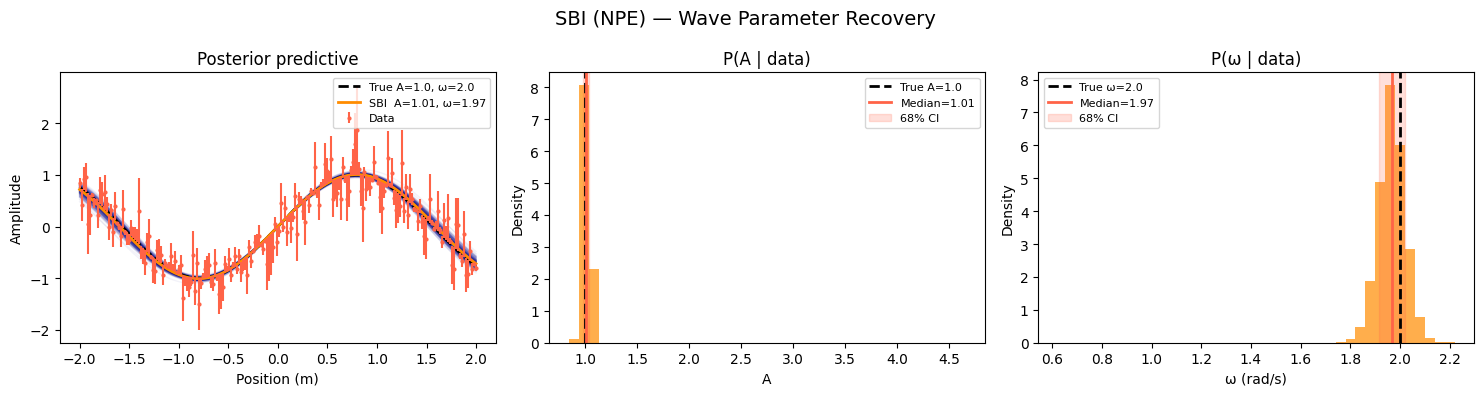

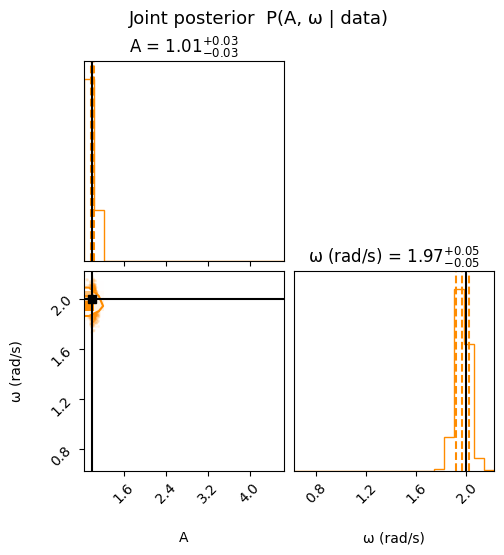


── Summary ─────────────────────────────────────────────
                  A        ω
True          1.000    2.000
SBI/NPE       1.008    1.967


In [18]:
# Example usage
study = WaveSBI(
    n_points     = 200,
    n_simulations = 10000,
    noise_std    = 0.3,
    true_A       = 1.0,
    true_omega   = 2.0,
    ncomponents  = 10,      # linear layer: 50 → 10
    hidden_dims  = [64, 64], # MLP hidden layers
    mlp_out_dim  = 16,      # final summary fed to NPE
)
study.run_all()